## Feature analysis: holidays

## Question

---

Is the binary `is_holiday` enough, or do we need a richer encoding of holidays?

Sub-questions (and where they are studied):

1. Demand across holidays varies a lot (1,000–7,400, mean ~4,500) — is this the holiday "type" or outside factors (growth, season)? — **§1**
2. Does temperature explain the spread? — **§2**
3. The main distorting factor is service growth (+65% over the year); do the features `is_holiday`, `days_since_launch`, `month` remove it? — **§1–2**
4. Does the weekday a holiday falls on matter? — **§3**
5. Do registered and direct behave differently on holidays? — **§4**

> **Data discipline.** Descriptive analysis over the full 2011–2012 period — to understand the data, not to select features.
> Feature and model selection happens on validation in [eda_and_modeling.ipynb](eda_and_modeling.ipynb); test stays untouched until the end.
> Using the full period here is safe because the conclusion is **conservative** (a coarse `is_holiday`, no rich encoding) —
> that is dropping a feature, not fitting to the data, so it cannot overfit the test. And splitting 21 holidays into train/test would be statistically meaningless anyway.

## Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw")

# Main data — from the pipeline output (asset hourly_by_location, single source of truth).
fd = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])
fd["date"] = fd["datetime_hourly"].dt.normalize()

# Holiday names — separately from holidays.csv: the name is only needed for the analysis
# here, it is not a model feature, so it does not go into the ML dataset.
holiday_names = pd.read_csv(DATA_RAW / "holidays.csv")
holiday_names["date"] = pd.to_datetime(holiday_names["date"]).dt.normalize()

## Daily aggregation

---

Daily table: total rentals (total / registered / direct), mean temperature, holiday flag and name, year and month.

In [3]:
# Daily aggregate from hourly_by_location: total / registered / direct per date (summed over locations),
# mean temperature, holiday flag. The holiday name is merged in from holiday_names.
daily = fd.groupby("date").agg(
    daily_rentals=("total_rentals", "sum"),
    daily_registered=("registered_rentals", "sum"),
    daily_direct=("direct_pickups", "sum"),
    avg_temp=("temperature_c", "mean"),
    is_holiday=("is_holiday", "max"),
).reset_index()
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["day_of_week"] = daily["date"].dt.dayofweek
daily = daily.merge(holiday_names[["date", "holiday"]], on="date", how="left")

regular = daily[daily["is_holiday"] == 0]
holidays_df = daily[daily["is_holiday"] == 1]
regular_day_mean = regular["daily_rentals"].mean()

print(f"Regular days: {len(regular)}, holidays: {len(holidays_df)}")
print(f"Average regular day: {regular_day_mean:,.0f} rentals")

Regular days: 710, holidays: 21
Average regular day: 4,527 rentals


## 1. Holiday effect: local ±15-day baseline

---

We compare each holiday's rentals to the average of **regular days within ±15 days** of it. This local baseline removes two distortions at once — service growth and season — because it uses "nearby conditions" instead of the average over the whole period (which changes a lot over time).

We measure the deviation in absolute terms and in **percent** (percentages are comparable across seasons: in summer both the baseline and the holiday are larger). We do not match the weekday in the baseline — the ordinary weekday effect is small (~4%, [trends §4](exploration_time_trends.ipynb)). Moving a holiday to Monday (observed) is a separate case, covered in §3. Holidays are excluded from the baseline.

In [4]:
WINDOW = pd.Timedelta(days=15)
reg_dates = pd.to_datetime(regular["date"])  # date -> Timestamp for window arithmetic

def local_base(holiday_date):
    """Mean of regular days within ±15 days of the holiday, plus the base size."""
    near = regular.loc[(reg_dates - pd.Timestamp(holiday_date)).abs() <= WINDOW, "daily_rentals"]
    return near.mean(), int(near.shape[0])

holidays_df = holidays_df.copy()
base = holidays_df["date"].map(local_base)
holidays_df["base_local"] = [b[0] for b in base]
holidays_df["n_base"] = [b[1] for b in base]
holidays_df["dev_abs"] = holidays_df["daily_rentals"] - holidays_df["base_local"]
holidays_df["dev_pct"] = holidays_df["dev_abs"] / holidays_df["base_local"] * 100

holiday_effect = holidays_df.sort_values("dev_pct")[
    ["date", "holiday", "year", "daily_rentals", "base_local", "dev_abs", "dev_pct"]
]
print(f"days in local base: min={holidays_df['n_base'].min()}  max={holidays_df['n_base'].max()}\n")
print(holiday_effect.round(1).to_string(index=False))
print(f"\nmedian: {holidays_df['dev_pct'].median():.0f}%   "
      f"drop >5%: {(holidays_df['dev_pct'] < -5).sum()}   "
      f"rise >5%: {(holidays_df['dev_pct'] > 5).sum()}   "
      f"within ±5%: {(holidays_df['dev_pct'].abs() <= 5).sum()}  (of {len(holidays_df)})")

days in local base: min=21  max=30

      date                                holiday  year  daily_rentals  base_local  dev_abs  dev_pct
2012-12-25                          Christmas Day  2012           1013      3576.1  -2563.1    -71.7
2011-11-24                       Thanksgiving Day  2011           1495      3242.5  -1747.5    -53.9
2011-12-26               Christmas Day (observed)  2011           1317      2834.0  -1517.0    -53.5
2012-11-22                       Thanksgiving Day  2012           2425      5163.4  -2738.4    -53.0
2011-02-21                  Washington's Birthday  2011           1107      1808.7   -701.7    -38.8
2012-01-02              New Year's Day (observed)  2012           1951      2716.9   -765.9    -28.2
2012-01-16 Dr. Martin Luther King, Jr.'s Birthday  2012           2298      3189.5   -891.5    -28.0
2012-10-08                           Columbus Day  2012           5478      7091.3  -1613.3    -22.8
2011-09-05                              Labor Day  2011

/tmp/claude-508/ipykernel_80859/3344321074.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(holiday_effect.round(1).to_string(index=False))


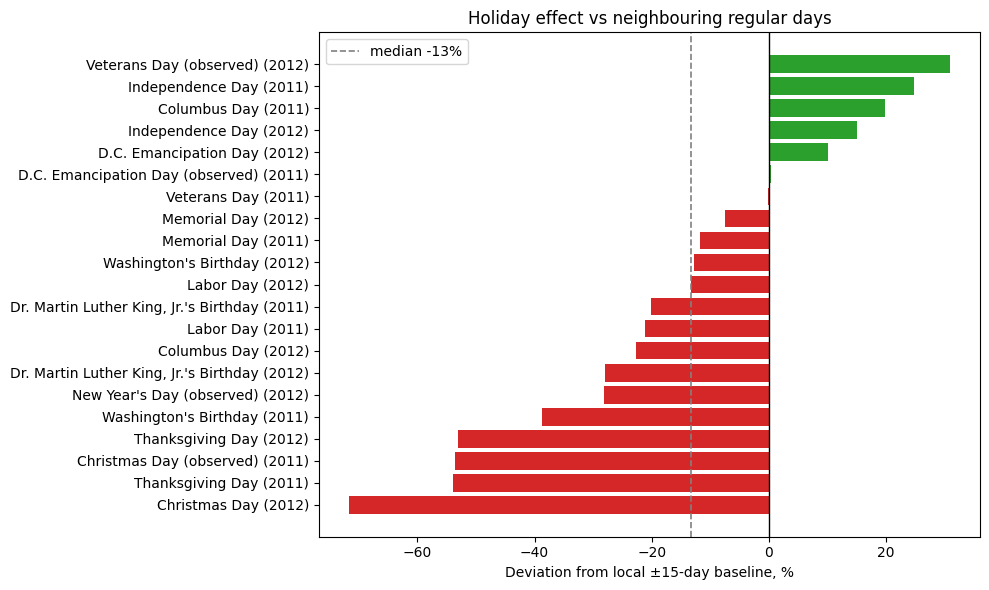

In [5]:
he = holidays_df.sort_values("dev_pct")
labels = he["holiday"] + " (" + he["year"].astype(str) + ")"
colors = ["#d62728" if v < 0 else "#2ca02c" for v in he["dev_pct"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, he["dev_pct"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(he["dev_pct"].median(), color="grey", linestyle="--", linewidth=1.2,
           label=f"median {he['dev_pct'].median():.0f}%")
ax.set_xlabel("Deviation from local ±15-day baseline, %")
ax.set_title("Holiday effect vs neighbouring regular days")
ax.legend()
plt.tight_layout()
plt.show()

### Observations

- With the local baseline the picture changes: a holiday more often **lowers** demand. The median deviation is **−13%**: of 21 holidays, 14 are below the neighbouring regular days (>5%) and only 5 are above. The whole-period average hid this — drops and rises cancelled out because seasons and growth were mixed in.
- The extreme cases make sense. The strongest drops are on winter/family holidays: Christmas −72%, Thanksgiving −54%, plus Washington, MLK, New Year. The rises are on "active", outdoor holidays: Independence Day (+25%/+15% by year), Veterans (observed) +31%, Columbus 2011.
- **But year over year the effect is unstable.** Of the 10 holidays present in both years, only 2 give a close value (within 5 p.p.); on average they differ by ~16 p.p., and two even flip sign (Columbus +20%→−23%, Veterans −0.2%→+31%). Part of the jumps comes from the move to Monday (observed, see §3), but Columbus jumps by 43 p.p. on the same Monday — so plain noise on a small sample remains.

**For the model:** the binary `is_holiday` averages everything into a −13% drop and loses the extremes. But encoding each holiday separately on 21 observations is risky — we would overfit. A reasonable minimum is three ordinary features `is_holiday`, `days_since_launch`, `month` (the tree picks up their interaction). We will test a richer encoding with an experiment (ablation) on the test set, but with low expectations — details in [eda_and_modeling.ipynb](eda_and_modeling.ipynb).

## 2. Cross-checks (brief)

---

The local baseline in §1 already controls for both growth and season. Here are the two short checks that led to it: do **temperature** and **service growth** explain the spread?

We compute `residual` (actual minus a linear temperature trend) here — it is needed in §3.

In [6]:
# Control for temperature: a linear trend over regular days, residual = actual − prediction.
coef = np.polyfit(regular["avg_temp"], regular["daily_rentals"], 1)
pred_fn = np.poly1d(coef)

regular = regular.copy()
holidays_df = holidays_df.copy()
regular["residual"] = regular["daily_rentals"] - pred_fn(regular["avg_temp"])
holidays_df["residual"] = holidays_df["daily_rentals"] - pred_fn(holidays_df["avg_temp"])

reg_std = regular["residual"].std()
outside_1std = (holidays_df["residual"].abs() > reg_std).sum()

# Growth: variation of the same holiday between years (in residuals).
paired = holidays_df.pivot_table(index="holiday", columns="year", values="residual").dropna()
cross_year = (paired[2012] - paired[2011]).abs().mean()

print(f"std of residuals, regular days:    {reg_std:,.0f}")
print(f"holidays beyond ±1 std after temp: {outside_1std} / {len(holidays_df)}  -> temperature does not explain it")
print(f"mean |year-to-year diff|:          {cross_year:,.0f}  (~ std of regular days)")

std of residuals, regular days:    1,512
holidays beyond ±1 std after temp: 8 / 21  -> temperature does not explain it
mean |year-to-year diff|:          1,659  (~ std of regular days)


### Observations

- **Temperature does not explain the spread.** Even after correcting for temperature, 8 of 21 holidays fall beyond ±1 std of regular days (std ≈ 1500). It is not the weather.
- **The main factor is growth.** The year-to-year difference of one holiday in residuals (~1660) is comparable to the std of regular days (~1500), which is why it used to look like noise. But the §1 local baseline showed the holiday is still unstable year over year — the baseline only partly removes growth, the rest is weekday and noise.
- Both checks are absorbed by the §1 local baseline, kept briefly as "how we got there". `residual` is used in §3.

## 3. The weekday of a holiday

---

Independence Day 2012 fell on a Wednesday and had the highest residual. We check: does a holiday's weekday correlate with its residual?

In [7]:
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hol_dow = holidays_df[["holiday", "year", "day_of_week", "residual"]].copy()
hol_dow["weekday"] = hol_dow["day_of_week"].map(dict(enumerate(dow_names)))

print(hol_dow.sort_values("residual")[["holiday", "year", "weekday", "residual"]].to_string(index=False))

                               holiday  year weekday     residual
                             Labor Day  2011     Mon -2339.534289
                      Thanksgiving Day  2011     Thu -2224.806009
                         Christmas Day  2012     Tue -2167.751926
                 Washington's Birthday  2011     Mon -2153.008212
              Christmas Day (observed)  2011     Mon -2064.777447
                          Memorial Day  2011     Mon -1985.399496
Dr. Martin Luther King, Jr.'s Birthday  2011     Mon -1425.387906
             New Year's Day (observed)  2012     Mon -1111.322995
                      Thanksgiving Day  2012     Thu -1076.547561
      D.C. Emancipation Day (observed)  2011     Fri -1075.720662
Dr. Martin Luther King, Jr.'s Birthday  2012     Mon  -218.183421
                          Veterans Day  2011     Fri   -29.365528
                      Independence Day  2011     Mon     2.670171
                 Washington's Birthday  2012     Mon    20.520088
          

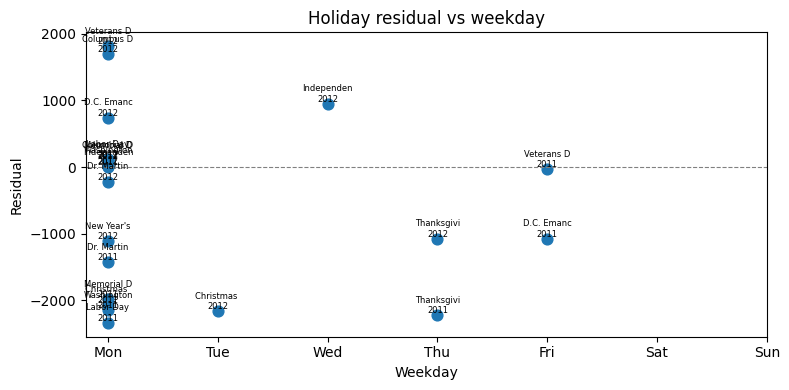

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(hol_dow["day_of_week"], hol_dow["residual"], s=60)
for _, row in hol_dow.iterrows():
    ax.annotate(f"{row['holiday'][:10]}\n{row['year']}",
                (row["day_of_week"], row["residual"]),
                fontsize=6, ha="center", va="bottom")
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Weekday")
ax.set_ylabel("Residual")
ax.set_title("Holiday residual vs weekday")
plt.tight_layout()
plt.show()

### Observations

- Almost all US holidays fall on a **Monday** (15 of 21), so there is almost no variation by weekday. And within Monday the residuals range from −2300 to +1800 — so it is not the weekday.
- §1 confirms this from another angle: part of the year-to-year jumps coincides with the move to Monday (Veterans Fri→Mon, Christmas Mon→Tue), but Columbus jumps by 43 p.p. on the same Monday. The weekday explains only part, the rest is noise.
- Independence Day on a Wednesday (2012, +953) vs a Monday (2011, +3) — too few points to conclude.

**For the model:** we do not add a separate "holiday weekday" feature — there is almost no variation, and within it only noise. The weekday is already in the model as the general feature `day_of_week`.

## 4. Registered vs direct on holidays

---

The two segments behave differently overall (4.3x in volume). The question: does the difference grow on holidays? If so, that is an argument for modelling them separately.

In [9]:
segment_daily = daily[["date", "is_holiday", "daily_registered", "daily_direct"]].copy()
segment_daily["reg_share"] = (
    segment_daily["daily_registered"]
    / (segment_daily["daily_registered"] + segment_daily["daily_direct"])
)

reg_share_regular = segment_daily[segment_daily["is_holiday"] == 0]["reg_share"]
reg_share_holiday = segment_daily[segment_daily["is_holiday"] == 1]["reg_share"]

print(f"Registered share (regular days):  mean={reg_share_regular.mean():.3f}, std={reg_share_regular.std():.3f}")
print(f"Registered share (holidays):      mean={reg_share_holiday.mean():.3f}, std={reg_share_holiday.std():.3f}")

Registered share (regular days):  mean=0.827, std=0.106
Registered share (holidays):      mean=0.728, std=0.125


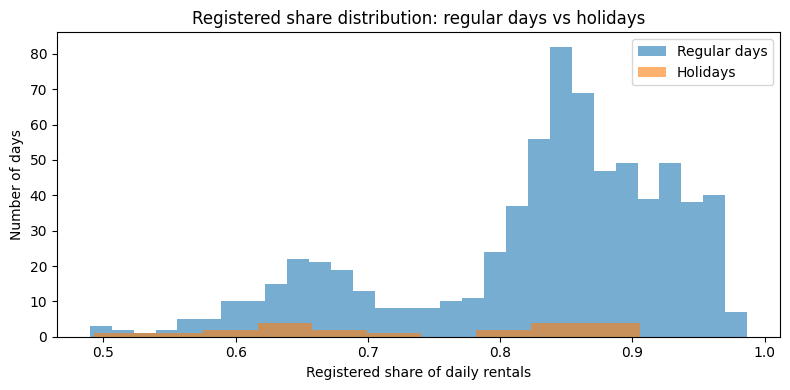

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(reg_share_regular, bins=30, alpha=0.6, label="Regular days")
ax.hist(reg_share_holiday, bins=10, alpha=0.6, label="Holidays")
ax.set_xlabel("Registered share of daily rentals")
ax.set_ylabel("Number of days")
ax.set_title("Registered share distribution: regular days vs holidays")
ax.legend()
plt.tight_layout()
plt.show()

### Observations

- On holidays the registered share **drops** from 0.83 to 0.73 — relatively more direct pickups (≈27% vs ≈17% on regular days). So the segments react to holidays differently.
- The signal is steady but moderate, and the spread on holidays is higher (std 0.11 → 0.13) — on 21 days this is weak support.

**For the model:** the difference is real, but on its own it does not justify separate models for `registered` and `direct` — that is extra complexity for a ~10 p.p. shift in share. For now we model total; a separate target stays an option (`config.target`) if per-segment accuracy is needed.

## Conclusions

---

**Confirmed:**
- The binary `is_holiday` is too coarse: it averages the effect (median −13%) and loses the extremes — winter/family holidays (drop down to −72%) vs active ones (rise up to +31%).
- But we cannot encode holidays in more detail on 21 observations — the effect is unstable year over year (only 2 of 10 match within 5 p.p., two flip sign), so we would overfit.
- The holiday spread is mostly growth and season, not the "type" itself (§1–2). The main factor is growth +65% (see [trends](exploration_time_trends.ipynb)); temperature is irrelevant.
- The holiday weekday (§3) and the registered/direct segment (§4) — the signal is weak, so we add no separate features or models.

**Recommendation: three separate features — `is_holiday`, `days_since_launch`, `month` (not a new aggregate).** `days_since_launch` removes growth, `month` gives season, and the tree partly recovers the holiday "type" through season (winter drops vs summer rises) without knowing the name. This is a compromise, not a full solution: a purely "type" residual (Memorial and Labor — summer, yet a drop) is unreliable on 21 days, so we test a richer encoding with an experiment (ablation) on the test set, without high expectations.